# Hotel Bar Inventory Demand Forecasting

## Project Objective

This project develops a data-driven inventory forecasting and replenishment approach for a hotel bar chain.

The main objectives are:

1. Clean and validate historical bar inventory transaction data.
2. Aggregate bottle consumption into daily demand by bar and brand.
3. Analyze demand patterns, high-velocity products, and stockouts.
4. Forecast future demand for individual bar-brand combinations.
5. Calculate recommended inventory par levels using demand and safety stock.
6. Simulate the inventory policy on historical data.
7. Evaluate the potential impact on stockouts and inventory levels.

## Business Problem

The hotel currently faces two inventory problems:

- Stockouts of high-demand products can affect guest satisfaction and revenue.
- Overstocking slow-moving products ties up working capital and storage space.

The goal is to balance product availability with efficient inventory levels.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
DATA_PATH = "../data/Consumption Dataset - Dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (6575, 8)


In [3]:
df.head()

,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)
0,1/1/2023 19:35,Smith's Bar,Rum,Captain Morgan,2555.04,1824.84,0.0,4379.88
1,1/1/2023 10:07,Smith's Bar,Wine,Yellow Tail,1344.37,0.00,0.0,1344.37
2,1/1/2023 11:26,Johnson's Bar,Vodka,Grey Goose,1034.28,0.00,0.0,1034.28
3,1/1/2023 13:53,Johnson's Bar,Beer,Coors,2194.53,0.00,0.0,2194.53
4,1/1/2023 22:28,Johnson's Bar,Wine,Yellow Tail,1020.90,0.00,0.0,1020.90


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6575 entries, 0 to 6574
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date Time Served      6575 non-null   object 
 1   Bar Name              6575 non-null   object 
 2   Alcohol Type          6575 non-null   object 
 3   Brand Name            6575 non-null   object 
 4   Opening Balance (ml)  6575 non-null   float64
 5   Purchase (ml)         6575 non-null   float64
 6   Consumed (ml)         6575 non-null   float64
 7   Closing Balance (ml)  6575 non-null   float64
dtypes: float64(4), object(4)
memory usage: 411.1+ KB


In [9]:
df.describe()

,Date Time Served,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)
count,6575,6575.000000,6575.000000,6575.000000,6575.000000
mean,2023-07-01 09:09:52.033459968,2468.397180,315.841757,299.419264,2484.811748
min,2023-01-01 10:07:00,0.000000,0.000000,0.000000,0.000000
25%,2023-03-30 19:35:00,619.135000,0.000000,156.640000,611.000000
50%,2023-06-30 18:08:00,1848.440000,0.000000,300.390000,1849.840000
75%,2023-10-01 13:59:30,3853.020000,526.345000,450.870000,3906.050000
max,2024-01-01 22:46:00,11862.520000,1999.840000,1180.580000,11862.520000
std,NaN,2284.552895,582.120264,191.903874,2302.363298


In [10]:
df.isnull().sum()

Date Time Served        0
Bar Name                0
Alcohol Type            0
Brand Name              0
Opening Balance (ml)    0
Purchase (ml)           0
Consumed (ml)           0
Closing Balance (ml)    0
Date                    0
dtype: int64

In [11]:
df["Date Time Served"] = pd.to_datetime(df["Date Time Served"])

df["Date"] = df["Date Time Served"].dt.date

print("Date conversion completed!")
print(df["Date Time Served"].dtype)

Date conversion completed!
datetime64[ns]


In [18]:
print("Start Date:", df["Date Time Served"].min())
print("End Date:", df["Date Time Served"].max())

Start Date: 2023-01-01 10:07:00
End Date: 2024-01-01 22:46:00


In [19]:
df["Calculated Closing (ml)"] = (
    df["Opening Balance (ml)"]
    + df["Purchase (ml)"]
    - df["Consumed (ml)"]
)

df["Difference (ml)"] = (
    df["Calculated Closing (ml)"]
    - df["Closing Balance (ml)"]
)

print("Maximum absolute difference:",
      df["Difference (ml)"].abs().max())

print("Rows with difference greater than 0.01 ml:",
      (df["Difference (ml)"].abs() > 0.01).sum())

Maximum absolute difference: 9.25
Rows with difference greater than 0.01 ml: 149


In [20]:
df[df["Difference (ml)"].abs() > 0.01][
    [
        "Date Time Served",
        "Bar Name",
        "Brand Name",
        "Opening Balance (ml)",
        "Purchase (ml)",
        "Consumed (ml)",
        "Closing Balance (ml)",
        "Difference (ml)"
    ]
].head(10)

,Date Time Served,Bar Name,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml),Difference (ml)
42,2023-01-03 20:00:00,Brown's Bar,Jim Beam,826.20,0.00,227.73,598.0,0.47
58,2023-01-04 10:45:00,Smith's Bar,Miller,2300.00,0.00,349.22,1950.0,0.78
99,2023-01-06 13:10:00,Johnson's Bar,Barefoot,1427.79,0.00,248.86,1180.0,-1.07
125,2023-01-07 14:01:00,Taylor's Bar,Jim Beam,2510.00,0.00,494.68,2010.0,5.32
143,2023-01-08 14:46:00,Taylor's Bar,Captain Morgan,126.78,1736.61,569.99,1290.0,3.40
162,2023-01-09 13:49:00,Brown's Bar,Coors,1860.00,0.00,444.47,1420.0,-4.47
174,2023-01-09 10:09:00,Thomas's Bar,Jameson,905.40,0.00,517.22,388.0,0.18
179,2023-01-10 20:13:00,Smith's Bar,Coors,2790.00,1416.82,583.52,3620.0,3.30
245,2023-01-13 22:04:00,Brown's Bar,Budweiser,4280.00,0.00,451.47,3830.0,-1.47
251,2023-01-13 17:21:00,Anderson's Bar,Jim Beam,2000.00,722.20,424.82,2300.0,-2.62


In [21]:
print("Number of bars:", df["Bar Name"].nunique())
print("Number of brands:", df["Brand Name"].nunique())
print("Number of alcohol types:", df["Alcohol Type"].nunique())

Number of bars: 6
Number of brands: 16
Number of alcohol types: 5


In [22]:
print("\nBars:")
print(df["Bar Name"].unique())

print("\nAlcohol Types:")
print(df["Alcohol Type"].unique())


Bars:
["Smith's Bar" "Johnson's Bar" "Brown's Bar" "Taylor's Bar"
 "Anderson's Bar" "Thomas's Bar"]

Alcohol Types:
['Rum' 'Wine' 'Vodka' 'Beer' 'Whiskey']


In [23]:
print("\nNumber of records per bar:")
print(df["Bar Name"].value_counts())


Number of records per bar:
Bar Name
Johnson's Bar     1106
Anderson's Bar    1102
Thomas's Bar      1101
Brown's Bar       1100
Taylor's Bar      1088
Smith's Bar       1078
Name: count, dtype: int64


In [24]:
print("Number of bars:", df["Bar Name"].nunique())
print("Number of brands:", df["Brand Name"].nunique())
print("Number of alcohol types:", df["Alcohol Type"].nunique())

Number of bars: 6
Number of brands: 16
Number of alcohol types: 5


In [25]:
print("Bars:")
print(df["Bar Name"].unique())

Bars:
["Smith's Bar" "Johnson's Bar" "Brown's Bar" "Taylor's Bar"
 "Anderson's Bar" "Thomas's Bar"]


In [26]:
print("Alcohol Types:")
print(df["Alcohol Type"].unique())

Alcohol Types:
['Rum' 'Wine' 'Vodka' 'Beer' 'Whiskey']


In [27]:
print("Number of records per bar:")
print(df["Bar Name"].value_counts())

Number of records per bar:
Bar Name
Johnson's Bar     1106
Anderson's Bar    1102
Thomas's Bar      1101
Brown's Bar       1100
Taylor's Bar      1088
Smith's Bar       1078
Name: count, dtype: int64


## Daily Demand Aggregation

The original dataset contains transaction-level inventory records.

For demand forecasting, we aggregate consumption by:

- Date
- Bar
- Brand

This produces a daily time series that can be used for demand forecasting and inventory planning.

In [28]:
daily_demand = (
    df.groupby(
        ["Date", "Bar Name", "Brand Name"],
        as_index=False
    )["Consumed (ml)"]
    .sum()
)

daily_demand = daily_demand.rename(
    columns={"Consumed (ml)": "Daily Demand (ml)"}
)

daily_demand.head()

,Date,Bar Name,Brand Name,Daily Demand (ml)
0,2023-01-01,Anderson's Bar,Bacardi,0.0
1,2023-01-01,Anderson's Bar,Jim Beam,0.0
2,2023-01-01,Anderson's Bar,Miller,0.0
3,2023-01-01,Anderson's Bar,Sutter Home,0.0
4,2023-01-01,Brown's Bar,Captain Morgan,0.0


In [29]:
print("Daily demand shape:", daily_demand.shape)
print("\nNumber of unique dates:", daily_demand["Date"].nunique())
print("Number of bars:", daily_demand["Bar Name"].nunique())
print("Number of brands:", daily_demand["Brand Name"].nunique())

Daily demand shape: (6575, 4)

Number of unique dates: 366
Number of bars: 6
Number of brands: 16


In [30]:
daily_demand["Daily Demand (ml)"].describe()

count    6575.000000
mean      299.419264
std       191.903874
min         0.000000
25%       156.640000
50%       300.390000
75%       450.870000
max      1180.580000
Name: Daily Demand (ml), dtype: float64

## Complete Daily Time Series

For forecasting, every bar-brand combination should have a record for every date in the dataset.

If a product had no recorded consumption on a particular day, we treat its demand as 0 ml rather than leaving the date missing.

In [31]:
# Create all combinations of dates, bars, and brands

all_dates = pd.date_range(
    start=df["Date Time Served"].min().normalize(),
    end=df["Date Time Served"].max().normalize(),
    freq="D"
)

all_bars = df["Bar Name"].unique()
all_brands = df["Brand Name"].unique()

full_grid = pd.MultiIndex.from_product(
    [all_dates, all_bars, all_brands],
    names=["Date", "Bar Name", "Brand Name"]
).to_frame(index=False)

print("Complete grid shape:", full_grid.shape)

Complete grid shape: (35136, 3)


In [32]:
daily_demand = full_grid.merge(
    daily_demand,
    on=["Date", "Bar Name", "Brand Name"],
    how="left"
)

daily_demand["Daily Demand (ml)"] = (
    daily_demand["Daily Demand (ml)"]
    .fillna(0)
)

daily_demand.head(10)

ValueError: You are trying to merge on datetime64[ns] and object columns for key 'Date'. If you wish to proceed you should use pd.concat

In [33]:
# Make both Date columns the same datetime type

daily_demand["Date"] = pd.to_datetime(daily_demand["Date"])
full_grid["Date"] = pd.to_datetime(full_grid["Date"])

print("Date types:")
print("daily_demand:", daily_demand["Date"].dtype)
print("full_grid:", full_grid["Date"].dtype)

Date types:
daily_demand: datetime64[ns]
full_grid: datetime64[ns]


In [34]:
daily_demand = full_grid.merge(
    daily_demand,
    on=["Date", "Bar Name", "Brand Name"],
    how="left"
)

daily_demand["Daily Demand (ml)"] = (
    daily_demand["Daily Demand (ml)"]
    .fillna(0)
)

daily_demand.head(10)

,Date,Bar Name,Brand Name,Daily Demand (ml)
0,2023-01-01,Smith's Bar,Captain Morgan,0.0
1,2023-01-01,Smith's Bar,Yellow Tail,0.0
2,2023-01-01,Smith's Bar,Grey Goose,0.0
3,2023-01-01,Smith's Bar,Coors,0.0
4,2023-01-01,Smith's Bar,Jim Beam,0.0
5,2023-01-01,Smith's Bar,Absolut,0.0
6,2023-01-01,Smith's Bar,Jack Daniels,0.0
7,2023-01-01,Smith's Bar,Sutter Home,0.0
8,2023-01-01,Smith's Bar,Miller,0.0
9,2023-01-01,Smith's Bar,Bacardi,0.0


In [35]:
print("Daily demand shape:", daily_demand.shape)
print(
    "Missing demand values:",
    daily_demand["Daily Demand (ml)"].isnull().sum()
)

Daily demand shape: (35136, 4)
Missing demand values: 0


In [36]:
zero_demand = (
    daily_demand["Daily Demand (ml)"] == 0
).sum()

total_records = len(daily_demand)

print("Zero-demand records:", zero_demand)
print("Total records:", total_records)

print(
    "Percentage of zero-demand records:",
    round((zero_demand / total_records) * 100, 2),
    "%"
)

Zero-demand records: 29471
Total records: 35136
Percentage of zero-demand records: 83.88 %


In [37]:
daily_demand["Daily Demand (ml)"].describe()

count    35136.000000
mean        56.030330
std        143.276492
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       1180.580000
Name: Daily Demand (ml), dtype: float64

## Exploratory Data Analysis

The objective of this section is to understand:

- Which brands have the highest demand?
- Which bars have the highest consumption?
- Does demand vary by day of the week?
- Which brands belong to high, medium, and low velocity groups?
- Where have historical stockouts occurred?

In [38]:
brand_consumption = (
    daily_demand.groupby("Brand Name")["Daily Demand (ml)"]
    .sum()
    .sort_values(ascending=False)
)

brand_consumption

Brand Name
Grey Goose        158924.02
Jim Beam          139702.43
Captain Morgan    138035.53
Barefoot          132312.95
Yellow Tail       129843.65
Smirnoff          129176.67
Bacardi           127951.80
Malibu            127279.51
Jack Daniels      125050.89
Absolut           123659.02
Jameson           120001.14
Sutter Home       117245.66
Miller            107719.33
Coors              97999.32
Heineken           96967.09
Budweiser          96812.65
Name: Daily Demand (ml), dtype: float64

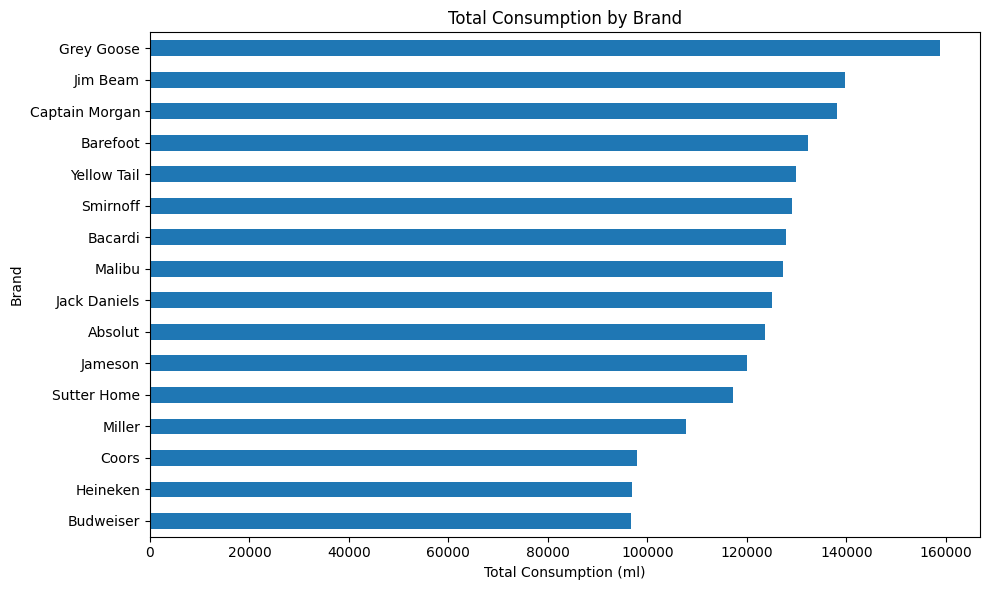

In [39]:
plt.figure(figsize=(10, 6))

brand_consumption.sort_values().plot(kind="barh")

plt.title("Total Consumption by Brand")
plt.xlabel("Total Consumption (ml)")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()

In [40]:
bar_consumption = (
    daily_demand.groupby("Bar Name")["Daily Demand (ml)"]
    .sum()
    .sort_values(ascending=False)
)

bar_consumption

Bar Name
Johnson's Bar     344184.38
Anderson's Bar    335818.95
Smith's Bar       328713.91
Brown's Bar       326371.92
Thomas's Bar      318415.94
Taylor's Bar      315176.56
Name: Daily Demand (ml), dtype: float64

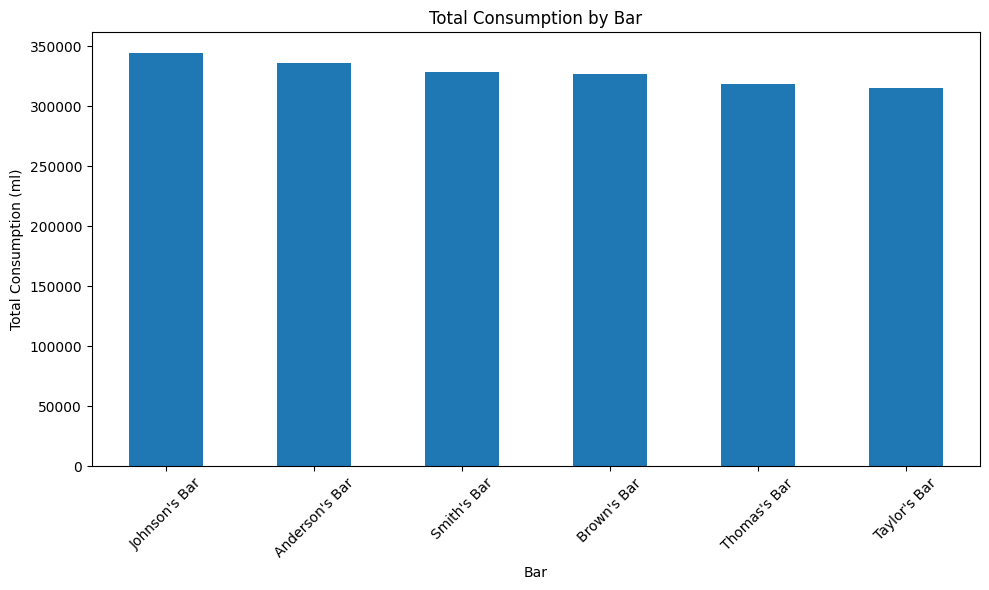

In [41]:
plt.figure(figsize=(10, 6))

bar_consumption.plot(kind="bar")

plt.title("Total Consumption by Bar")
plt.xlabel("Bar")
plt.ylabel("Total Consumption (ml)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
daily_demand["Day of Week"] = daily_demand["Date"].dt.day_name()

In [43]:
dow_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

dow_consumption = (
    daily_demand.groupby("Day of Week")["Daily Demand (ml)"]
    .mean()
    .reindex(dow_order)
)

dow_consumption

Day of Week
Monday       53.224733
Tuesday      56.017458
Wednesday    58.503101
Thursday     55.643606
Friday       56.826180
Saturday     56.474858
Sunday       55.584892
Name: Daily Demand (ml), dtype: float64

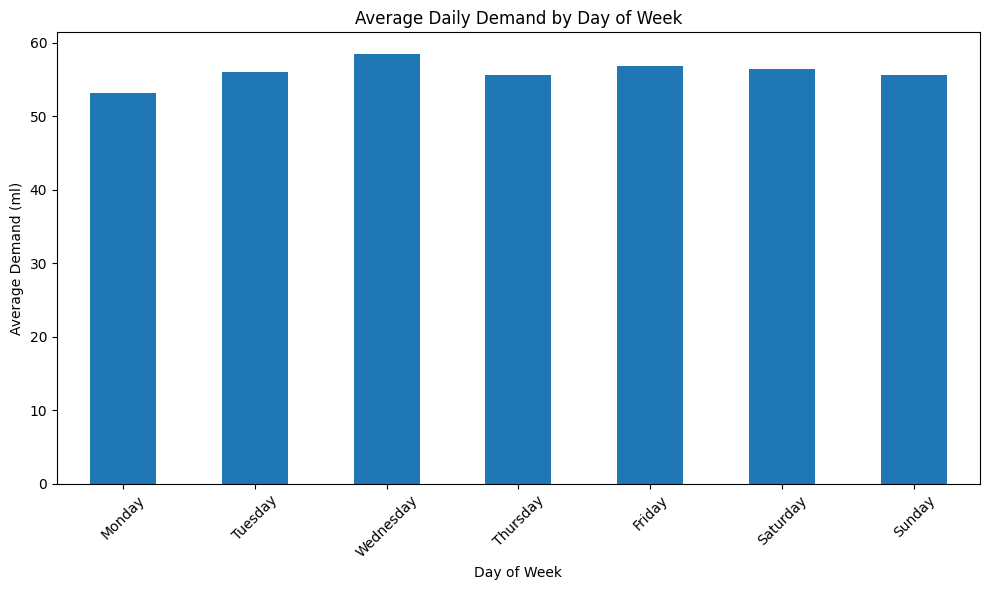

In [44]:
plt.figure(figsize=(10, 6))

dow_consumption.plot(kind="bar")

plt.title("Average Daily Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand (ml)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ABC Analysis

ABC analysis categorizes brands based on their contribution to total consumption.

- A: High-velocity brands contributing to approximately the first 80% of consumption.
- B: Medium-velocity brands contributing to the next 15%.
- C: Lower-velocity brands contributing to the remaining consumption.

This helps prioritize inventory management and forecasting effort.

In [45]:
abc = brand_consumption.reset_index()

abc.columns = ["Brand Name", "Total Consumption (ml)"]

abc["Cumulative Consumption"] = (
    abc["Total Consumption (ml)"].cumsum()
)

abc["Cumulative Percentage"] = (
    abc["Cumulative Consumption"]
    / abc["Total Consumption (ml)"].sum()
    * 100
)

abc["ABC Category"] = pd.cut(
    abc["Cumulative Percentage"],
    bins=[0, 80, 95, 100],
    labels=["A", "B", "C"],
    include_lowest=True
)

abc

,Brand Name,Total Consumption (ml),Cumulative Consumption,Cumulative Percentage,ABC Category
0,Grey Goose,158924.02,158924.02,8.072611,A
1,Jim Beam,139702.43,298626.45,15.168854,A
2,Captain Morgan,138035.53,436661.98,22.180426,A
3,Barefoot,132312.95,568974.93,28.901317,A
4,Yellow Tail,129843.65,698818.58,35.496779,A
5,Smirnoff,129176.67,827995.25,42.058362,A
6,Bacardi,127951.80,955947.05,48.557726,A
7,Malibu,127279.51,1083226.56,55.022942,A
8,Jack Daniels,125050.89,1208277.45,61.374953,A
9,Absolut,123659.02,1331936.47,67.656264,A


In [46]:
abc["ABC Category"].value_counts().sort_index()

ABC Category
A    12
B     2
C     2
Name: count, dtype: int64

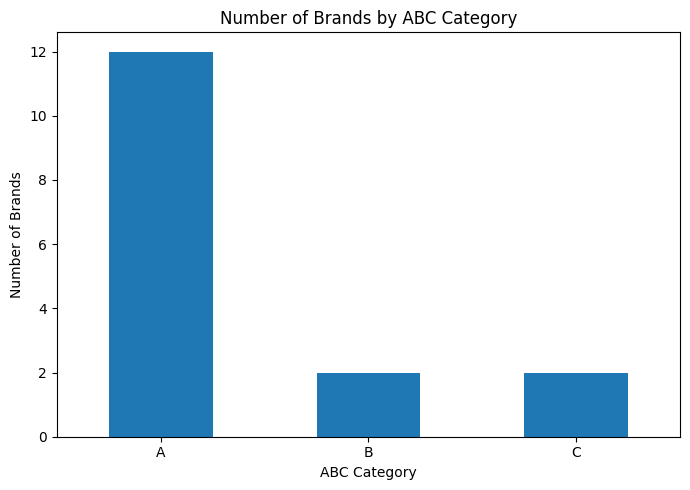

In [47]:
plt.figure(figsize=(7, 5))

abc["ABC Category"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Number of Brands by ABC Category")
plt.xlabel("ABC Category")
plt.ylabel("Number of Brands")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Historical Stockout Audit

A potential stockout is identified when the recorded closing inventory is zero or effectively zero while consumption was recorded for the transaction.

This is used as a historical indicator of inventory availability problems.

In [48]:
stockout_mask = (
    (df["Closing Balance (ml)"] <= 0.01)
    & (df["Consumed (ml)"] > 0)
)

stockouts = df[stockout_mask].copy()

print("Potential stockout transactions:", len(stockouts))

Potential stockout transactions: 264


In [49]:
stockouts[
    [
        "Date Time Served",
        "Bar Name",
        "Brand Name",
        "Consumed (ml)",
        "Closing Balance (ml)"
    ]
].head(10)

,Date Time Served,Bar Name,Brand Name,Consumed (ml),Closing Balance (ml)
84,2023-01-05 12:48:00,Taylor's Bar,Heineken,398.16,0.000000e+00
102,2023-01-06 11:51:00,Brown's Bar,Bacardi,145.81,0.000000e+00
133,2023-01-07 22:34:00,Thomas's Bar,Coors,161.86,0.000000e+00
139,2023-01-08 15:47:00,Johnson's Bar,Yellow Tail,387.26,5.680000e-14
146,2023-01-08 19:18:00,Anderson's Bar,Absolut,275.08,1.710000e-13
151,2023-01-08 10:35:00,Thomas's Bar,Barefoot,226.31,8.530000e-14
194,2023-01-11 16:04:00,Smith's Bar,Jim Beam,487.92,0.000000e+00
198,2023-01-11 18:14:00,Johnson's Bar,Jim Beam,319.86,0.000000e+00
256,2023-01-13 14:18:00,Thomas's Bar,Jameson,388.18,0.000000e+00
264,2023-01-14 11:48:00,Brown's Bar,Jim Beam,102.45,4.260000e-14


## Demand Forecasting

The forecasting objective is to predict daily demand for each bar-brand combination.

A chronological train-validation split is used instead of random splitting because future observations should not be used to predict the past.

Two approaches are compared:

1. 7-day rolling mean baseline
2. Random Forest regression model

The models are evaluated using MAE, RMSE, and WAPE.

In [50]:
forecast_df = daily_demand.copy()

# Sort the data
forecast_df = forecast_df.sort_values(
    ["Bar Name", "Brand Name", "Date"]
).reset_index(drop=True)

# Previous-day demand
forecast_df["Lag_1"] = (
    forecast_df
    .groupby(["Bar Name", "Brand Name"])["Daily Demand (ml)"]
    .shift(1)
)

# Demand from 7 days ago
forecast_df["Lag_7"] = (
    forecast_df
    .groupby(["Bar Name", "Brand Name"])["Daily Demand (ml)"]
    .shift(7)
)

# Previous 7-day average demand
forecast_df["Rolling_Mean_7"] = (
    forecast_df
    .groupby(["Bar Name", "Brand Name"])["Daily Demand (ml)"]
    .transform(
        lambda x: x.shift(1).rolling(7, min_periods=1).mean()
    )
)

# Previous 7-day demand variability
forecast_df["Rolling_Std_7"] = (
    forecast_df
    .groupby(["Bar Name", "Brand Name"])["Daily Demand (ml)"]
    .transform(
        lambda x: x.shift(1).rolling(7, min_periods=2).std()
    )
)

# Calendar features
forecast_df["Day_of_Week"] = forecast_df["Date"].dt.dayofweek
forecast_df["Month"] = forecast_df["Date"].dt.month
forecast_df["Is_Weekend"] = (
    forecast_df["Day_of_Week"] >= 5
).astype(int)

forecast_df.head()

,Date,Bar Name,Brand Name,Daily Demand (ml),Day of Week,Lag_1,Lag_7,Rolling_Mean_7,Rolling_Std_7,Day_of_Week,Month,Is_Weekend
0,2023-01-01,Anderson's Bar,Absolut,0.00,Sunday,NaN,NaN,NaN,NaN,6,1,1
1,2023-01-02,Anderson's Bar,Absolut,118.62,Monday,0.00,NaN,0.000,NaN,0,1,0
2,2023-01-03,Anderson's Bar,Absolut,0.00,Tuesday,118.62,NaN,59.310,83.877006,1,1,0
3,2023-01-04,Anderson's Bar,Absolut,0.00,Wednesday,0.00,NaN,39.540,68.485289,2,1,0
4,2023-01-05,Anderson's Bar,Absolut,463.20,Thursday,0.00,NaN,29.655,59.310000,3,1,0


In [51]:
split_date = forecast_df["Date"].quantile(0.80)

print("Split date:", split_date)

Split date: 2023-10-20 00:00:00


In [52]:
train = forecast_df[
    forecast_df["Date"] < split_date
].copy()

test = forecast_df[
    forecast_df["Date"] >= split_date
].copy()

print("Training rows:", len(train))
print("Testing rows:", len(test))
print("Training end date:", train["Date"].max())
print("Testing start date:", test["Date"].min())

Training rows: 28032
Testing rows: 7104
Training end date: 2023-10-19 00:00:00
Testing start date: 2023-10-20 00:00:00


In [53]:
train = train.dropna(
    subset=["Lag_1", "Lag_7", "Rolling_Mean_7"]
)

test = test.dropna(
    subset=["Lag_1", "Lag_7", "Rolling_Mean_7"]
)

print("Training rows after removing missing features:", len(train))
print("Testing rows after removing missing features:", len(test))

Training rows after removing missing features: 27360
Testing rows after removing missing features: 7104


## Baseline Forecast — 7-Day Rolling Mean

As a simple benchmark, we predict each day's demand using the average demand observed during the previous 7 days for the same bar-brand combination.

This provides a baseline against which the machine learning model can be compared.

In [54]:
test["Baseline_Prediction"] = test["Rolling_Mean_7"]

print(
    test[
        [
            "Date",
            "Bar Name",
            "Brand Name",
            "Daily Demand (ml)",
            "Baseline_Prediction"
        ]
    ].head(10)
)

          Date        Bar Name Brand Name  Daily Demand (ml)  \
292 2023-10-20  Anderson's Bar    Absolut               0.00   
293 2023-10-21  Anderson's Bar    Absolut               0.00   
294 2023-10-22  Anderson's Bar    Absolut               0.00   
295 2023-10-23  Anderson's Bar    Absolut               0.00   
296 2023-10-24  Anderson's Bar    Absolut             174.39   
297 2023-10-25  Anderson's Bar    Absolut               0.00   
298 2023-10-26  Anderson's Bar    Absolut               0.00   
299 2023-10-27  Anderson's Bar    Absolut               0.00   
300 2023-10-28  Anderson's Bar    Absolut               0.00   
301 2023-10-29  Anderson's Bar    Absolut               0.00   

     Baseline_Prediction  
292           118.264286  
293           118.264286  
294           118.264286  
295            71.728571  
296            71.728571  
297            96.641429  
298            96.641429  
299            24.912857  
300            24.912857  
301            24.912857 

In [56]:
def calculate_wape(actual, predicted):
    denominator = np.sum(np.abs(actual))
    
    if denominator == 0:
        return np.nan
    
    return np.sum(np.abs(actual - predicted)) / denominator * 100

In [57]:
baseline_mae = mean_absolute_error(
    test["Daily Demand (ml)"],
    test["Baseline_Prediction"]
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        test["Daily Demand (ml)"],
        test["Baseline_Prediction"]
    )
)

baseline_wape = calculate_wape(
    test["Daily Demand (ml)"],
    test["Baseline_Prediction"]
)

print("Baseline MAE:", round(baseline_mae, 2))
print("Baseline RMSE:", round(baseline_rmse, 2))
print("Baseline WAPE:", round(baseline_wape, 2), "%")

Baseline MAE: 92.62
Baseline RMSE: 153.2
Baseline WAPE: 166.26 %


In [58]:
features = [
    "Lag_1",
    "Lag_7",
    "Rolling_Mean_7",
    "Rolling_Std_7",
    "Day_of_Week",
    "Month",
    "Is_Weekend"
]

target = "Daily Demand (ml)"

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (27360, 7)
X_test shape: (7104, 7)


In [59]:
rf_model = RandomForestRegressor(
    n_estimators=250,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [60]:
test["RF_Prediction"] = rf_model.predict(X_test)

test[
    [
        "Date",
        "Bar Name",
        "Brand Name",
        "Daily Demand (ml)",
        "Baseline_Prediction",
        "RF_Prediction"
    ]
].head(10)

,Date,Bar Name,Brand Name,Daily Demand (ml),Baseline_Prediction,RF_Prediction
292,2023-10-20,Anderson's Bar,Absolut,0.00,118.264286,57.602741
293,2023-10-21,Anderson's Bar,Absolut,0.00,118.264286,54.385720
294,2023-10-22,Anderson's Bar,Absolut,0.00,118.264286,48.355594
295,2023-10-23,Anderson's Bar,Absolut,0.00,71.728571,54.560029
296,2023-10-24,Anderson's Bar,Absolut,174.39,71.728571,54.321900
297,2023-10-25,Anderson's Bar,Absolut,0.00,96.641429,61.266130
298,2023-10-26,Anderson's Bar,Absolut,0.00,96.641429,38.356407
299,2023-10-27,Anderson's Bar,Absolut,0.00,24.912857,52.855508
300,2023-10-28,Anderson's Bar,Absolut,0.00,24.912857,54.053405
301,2023-10-29,Anderson's Bar,Absolut,0.00,24.912857,53.903555


In [61]:
rf_mae = mean_absolute_error(
    test["Daily Demand (ml)"],
    test["RF_Prediction"]
)

rf_rmse = np.sqrt(
    mean_squared_error(
        test["Daily Demand (ml)"],
        test["RF_Prediction"]
    )
)

rf_wape = calculate_wape(
    test["Daily Demand (ml)"],
    test["RF_Prediction"]
)

print("Random Forest MAE:", round(rf_mae, 2))
print("Random Forest RMSE:", round(rf_rmse, 2))
print("Random Forest WAPE:", round(rf_wape, 2), "%")

Random Forest MAE: 94.64
Random Forest RMSE: 144.66
Random Forest WAPE: 169.89 %


In [62]:
comparison = pd.DataFrame({
    "Model": [
        "7-Day Rolling Mean",
        "Random Forest"
    ],
    "MAE (ml)": [
        baseline_mae,
        rf_mae
    ],
    "RMSE (ml)": [
        baseline_rmse,
        rf_rmse
    ],
    "WAPE (%)": [
        baseline_wape,
        rf_wape
    ]
})

comparison.round(2)

,Model,MAE (ml),RMSE (ml),WAPE (%)
0,7-Day Rolling Mean,92.62,153.20,166.26
1,Random Forest,94.64,144.66,169.89


In [63]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

feature_importance

Rolling_Mean_7    0.261335
Rolling_Std_7     0.246546
Lag_7             0.129087
Month             0.123750
Lag_1             0.115203
Day_of_Week       0.112690
Is_Weekend        0.011390
dtype: float64

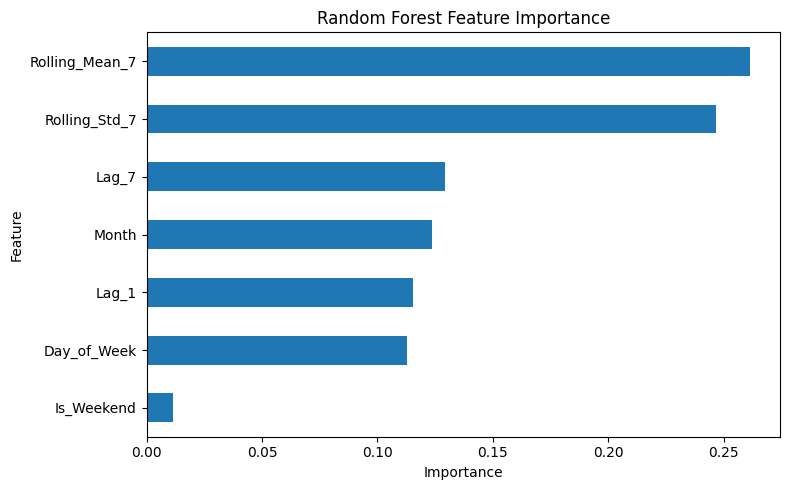

In [64]:
plt.figure(figsize=(8, 5))

feature_importance.sort_values().plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Inventory Par-Level Recommendation

The forecast is converted into an inventory recommendation using:

Par Level = Lead-Time Demand + Safety Stock

Assumptions:

- Lead time = 2 days
- Target service level = 95%
- Service-level z-score = 1.645
- Demand uncertainty is estimated using recent daily demand variability.

The par level represents the target inventory quantity that should be available to cover expected demand during replenishment.

In [65]:
LEAD_TIME_DAYS = 2
SERVICE_LEVEL_Z = 1.645

print("Lead time:", LEAD_TIME_DAYS, "days")
print("Target service level: 95%")
print("Z-score:", SERVICE_LEVEL_Z)

Lead time: 2 days
Target service level: 95%
Z-score: 1.645


In [66]:
inventory_stats = (
    train
    .groupby(["Bar Name", "Brand Name"])["Daily Demand (ml)"]
    .agg(
        Mean_Daily_Demand="mean",
        Std_Daily_Demand="std"
    )
    .reset_index()
)

inventory_stats.head()

,Bar Name,Brand Name,Mean_Daily_Demand,Std_Daily_Demand
0,Anderson's Bar,Absolut,29.367088,93.364201
1,Anderson's Bar,Bacardi,74.596912,162.787512
2,Anderson's Bar,Barefoot,78.266140,164.302673
3,Anderson's Bar,Budweiser,35.306281,111.519025
4,Anderson's Bar,Captain Morgan,76.773895,181.030667


In [67]:
inventory_stats["Lead_Time_Demand"] = (
    inventory_stats["Mean_Daily_Demand"]
    * LEAD_TIME_DAYS
)

In [68]:
inventory_stats["Safety_Stock"] = (
    SERVICE_LEVEL_Z
    * inventory_stats["Std_Daily_Demand"].fillna(0)
    * np.sqrt(LEAD_TIME_DAYS)
)

In [69]:
inventory_stats["Par_Level"] = (
    inventory_stats["Lead_Time_Demand"]
    + inventory_stats["Safety_Stock"]
)

In [70]:
inventory_stats.sort_values(
    "Par_Level",
    ascending=False
).head(20)

,Bar Name,Brand Name,Mean_Daily_Demand,Std_Daily_Demand,Lead_Time_Demand,Safety_Stock,Par_Level
4,Anderson's Bar,Captain Morgan,76.773895,181.030667,153.547789,421.146361,574.694150
45,Johnson's Bar,Smirnoff,74.846211,170.762987,149.692421,397.259822,546.952243
31,Brown's Bar,Yellow Tail,80.466561,165.085435,160.933123,384.051670,544.984793
48,Smith's Bar,Absolut,75.790737,167.100828,151.581474,388.740244,540.321718
36,Johnson's Bar,Captain Morgan,81.045088,162.161483,162.090175,377.249443,539.339618
2,Anderson's Bar,Barefoot,78.266140,164.302673,156.532281,382.230668,538.762949
67,Taylor's Bar,Budweiser,69.692877,169.847532,139.385754,395.130124,534.515878
90,Thomas's Bar,Jim Beam,72.839263,164.701612,145.678526,383.158752,528.837278
1,Anderson's Bar,Bacardi,74.596912,162.787512,149.193825,378.705824,527.899649
88,Thomas's Bar,Jack Daniels,73.811614,163.077499,147.623228,379.380447,527.003675


## Inventory Policy Simulation

The recommended par levels are evaluated through a historical inventory simulation.

The simulation assumes:

- Initial inventory is set to the recommended par level.
- Actual daily demand is deducted from inventory.
- When inventory falls below the replenishment point, an order is placed.
- Orders arrive after the assumed lead time.
- The order quantity brings inventory back up to the recommended par level.

The simulation tracks stockout days, lost demand, average inventory, and number of orders.

In [71]:
def simulate_inventory(demand_series, par_level, lead_time=2):
    
    inventory = par_level
    pending_orders = []
    
    stockout_days = 0
    lost_volume = 0
    total_inventory = 0
    order_count = 0
    
    for date, demand in demand_series.items():
        
        # Receive orders whose lead time has finished
        received_today = sum(
            quantity
            for arrival_date, quantity in pending_orders
            if arrival_date <= date
        )
        
        inventory += received_today
        
        # Remove received orders
        pending_orders = [
            (arrival_date, quantity)
            for arrival_date, quantity in pending_orders
            if arrival_date > date
        ]
        
        # Fulfill demand
        actual_demand = demand
        
        if inventory >= actual_demand:
            inventory -= actual_demand
        else:
            lost_volume += actual_demand - inventory
            inventory = 0
            stockout_days += 1
        
        total_inventory += inventory
        
        # Reorder when inventory falls below par level
        if inventory < par_level and not pending_orders:
            
            order_quantity = par_level - inventory
            
            arrival_date = date + pd.Timedelta(days=lead_time)
            
            pending_orders.append(
                (arrival_date, order_quantity)
            )
            
            order_count += 1
    
    average_inventory = total_inventory / len(demand_series)
    
    return {
        "stockout_days": stockout_days,
        "lost_volume_ml": lost_volume,
        "average_inventory_ml": average_inventory,
        "orders": order_count
    }

In [72]:
example = (
    daily_demand[
        (daily_demand["Bar Name"] == "Anderson's Bar") &
        (daily_demand["Brand Name"] == "Captain Morgan")
    ]
    .set_index("Date")["Daily Demand (ml)"]
)

example_par = inventory_stats[
    (inventory_stats["Bar Name"] == "Anderson's Bar") &
    (inventory_stats["Brand Name"] == "Captain Morgan")
]["Par_Level"].iloc[0]

example_result = simulate_inventory(
    example,
    example_par,
    LEAD_TIME_DAYS
)

example_result

{'stockout_days': 22,
 'lost_volume_ml': 4885.637745054439,
 'average_inventory_ml': 447.1010145031225,
 'orders': 65}

In [73]:
simulation_results = []

for _, row in inventory_stats.iterrows():
    
    bar = row["Bar Name"]
    brand = row["Brand Name"]
    par_level = row["Par_Level"]
    
    demand_series = (
        daily_demand[
            (daily_demand["Bar Name"] == bar) &
            (daily_demand["Brand Name"] == brand)
        ]
        .set_index("Date")["Daily Demand (ml)"]
        .sort_index()
    )
    
    result = simulate_inventory(
        demand_series,
        par_level,
        LEAD_TIME_DAYS
    )
    
    result["Bar Name"] = bar
    result["Brand Name"] = brand
    result["Par_Level"] = par_level
    
    simulation_results.append(result)

simulation_results = pd.DataFrame(simulation_results)

simulation_results.head()

,stockout_days,lost_volume_ml,average_inventory_ml,orders,Bar Name,Brand Name,Par_Level
0,25,3938.672012,225.323445,42,Anderson's Bar,Absolut,275.934909
1,20,2462.515967,394.234605,66,Anderson's Bar,Bacardi,527.899649
2,15,3462.414610,404.233754,73,Anderson's Bar,Barefoot,538.762949
3,16,2631.453294,288.114889,30,Anderson's Bar,Budweiser,330.048336
4,22,4885.637745,447.101015,65,Anderson's Bar,Captain Morgan,574.694150


In [74]:
print("Number of bar-brand combinations:",
      len(simulation_results))

simulation_results.head(10)

Number of bar-brand combinations: 96


,stockout_days,lost_volume_ml,average_inventory_ml,orders,Bar Name,Brand Name,Par_Level
0,25,3938.672012,225.323445,42,Anderson's Bar,Absolut,275.934909
1,20,2462.515967,394.234605,66,Anderson's Bar,Bacardi,527.899649
2,15,3462.414610,404.233754,73,Anderson's Bar,Barefoot,538.762949
3,16,2631.453294,288.114889,30,Anderson's Bar,Budweiser,330.048336
4,22,4885.637745,447.101015,65,Anderson's Bar,Captain Morgan,574.694150
5,22,4199.576583,354.488202,53,Anderson's Bar,Coors,450.840190
6,19,2944.519139,391.895789,64,Anderson's Bar,Grey Goose,512.823381
7,22,3941.900326,347.984756,42,Anderson's Bar,Heineken,424.253667
8,27,3534.207272,324.495781,61,Anderson's Bar,Jack Daniels,424.367075
9,22,4120.700904,387.279125,63,Anderson's Bar,Jameson,493.515955


In [75]:
simulation_results[
    [
        "Bar Name",
        "Brand Name",
        "Par_Level",
        "stockout_days",
        "lost_volume_ml",
        "average_inventory_ml",
        "orders"
    ]
].head(20)

,Bar Name,Brand Name,Par_Level,stockout_days,lost_volume_ml,average_inventory_ml,orders
0,Anderson's Bar,Absolut,275.934909,25,3938.672012,225.323445,42
1,Anderson's Bar,Bacardi,527.899649,20,2462.515967,394.234605,66
2,Anderson's Bar,Barefoot,538.762949,15,3462.414610,404.233754,73
3,Anderson's Bar,Budweiser,330.048336,16,2631.453294,288.114889,30
4,Anderson's Bar,Captain Morgan,574.694150,22,4885.637745,447.101015,65
5,Anderson's Bar,Coors,450.840190,22,4199.576583,354.488202,53
6,Anderson's Bar,Grey Goose,512.823381,19,2944.519139,391.895789,64
7,Anderson's Bar,Heineken,424.253667,22,3941.900326,347.984756,42
8,Anderson's Bar,Jack Daniels,424.367075,27,3534.207272,324.495781,61
9,Anderson's Bar,Jameson,493.515955,22,4120.700904,387.279125,63


In [76]:
print("Total stockout days:",
      simulation_results["stockout_days"].sum())

print("Total lost volume (ml):",
      round(simulation_results["lost_volume_ml"].sum(), 2))

print("Average inventory across combinations (ml):",
      round(simulation_results["average_inventory_ml"].mean(), 2))

print("Total orders:",
      simulation_results["orders"].sum())

Total stockout days: 2185
Total lost volume (ml): 352564.81
Average inventory across combinations (ml): 346.17
Total orders: 5275


In [77]:
simulation_results.sort_values(
    "stockout_days",
    ascending=False
).head(10)

,stockout_days,lost_volume_ml,average_inventory_ml,orders,Bar Name,Brand Name,Par_Level
77,32,3776.992149,342.745247,56,Taylor's Bar,Smirnoff,451.349209
38,31,5495.640837,376.270184,62,Johnson's Bar,Grey Goose,490.197689
29,31,4879.302806,300.467843,41,Brown's Bar,Smirnoff,366.870343
42,31,4976.267316,297.250177,41,Johnson's Bar,Jim Beam,363.065334
73,30,4217.635218,324.664868,59,Taylor's Bar,Jameson,420.651077
39,29,3543.011988,312.127171,55,Johnson's Bar,Heineken,402.250693
62,29,4703.192824,317.557943,59,Smith's Bar,Sutter Home,414.277087
64,28,4161.158057,319.761790,49,Taylor's Bar,Absolut,401.636452
93,28,3092.066312,311.289128,58,Thomas's Bar,Smirnoff,411.710987
86,28,3519.321457,360.773564,73,Thomas's Bar,Grey Goose,500.287207


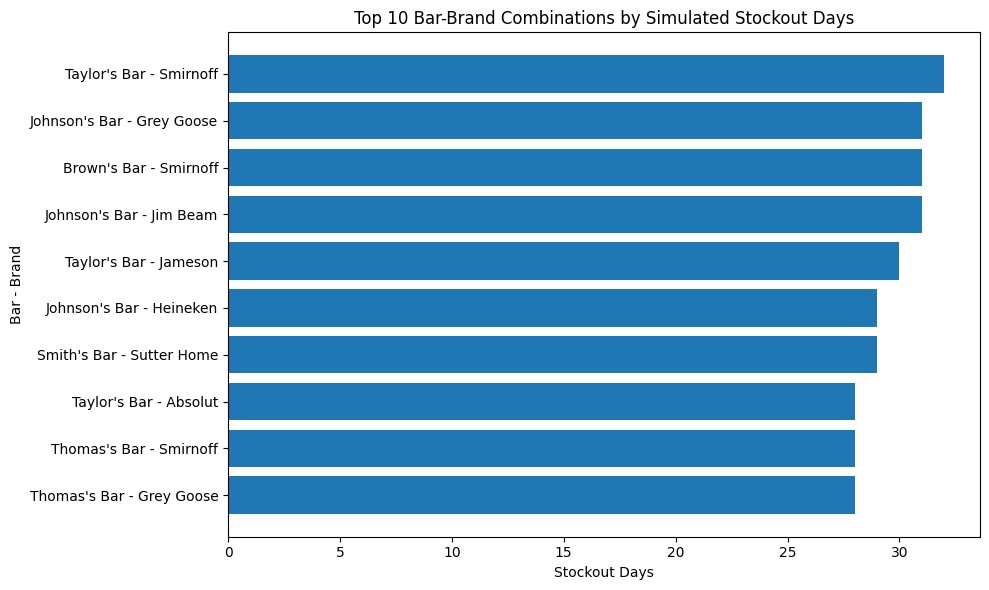

In [78]:
top_stockouts = (
    simulation_results
    .sort_values("stockout_days", ascending=False)
    .head(10)
    .copy()
)

plt.figure(figsize=(10, 6))

labels = (
    top_stockouts["Bar Name"]
    + " - "
    + top_stockouts["Brand Name"]
)

plt.barh(labels, top_stockouts["stockout_days"])

plt.xlabel("Stockout Days")
plt.ylabel("Bar - Brand")
plt.title("Top 10 Bar-Brand Combinations by Simulated Stockout Days")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

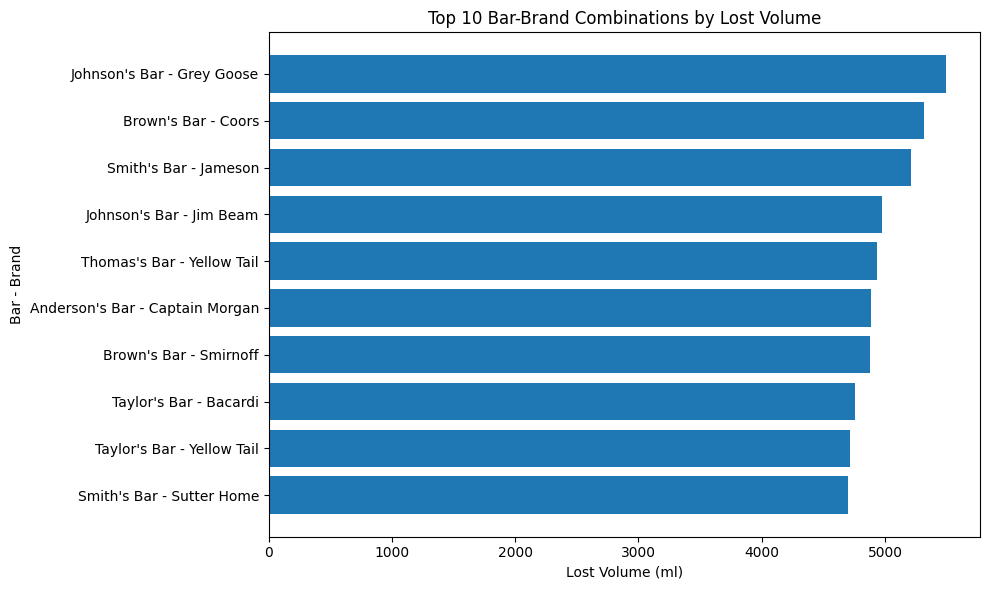

In [79]:
top_lost_volume = simulation_results.sort_values(
    "lost_volume_ml",
    ascending=False
).head(10)

top_lost_volume["Combination"] = (
    top_lost_volume["Bar Name"] + " - " +
    top_lost_volume["Brand Name"]
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_lost_volume["Combination"],
    top_lost_volume["lost_volume_ml"]
)

plt.xlabel("Lost Volume (ml)")
plt.ylabel("Bar - Brand")
plt.title("Top 10 Bar-Brand Combinations by Lost Volume")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

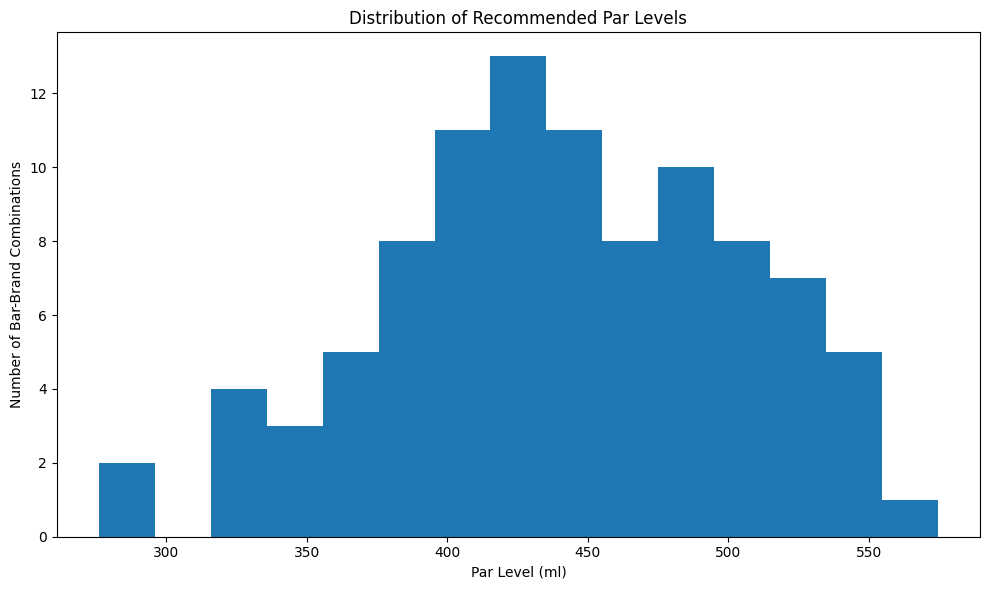

In [80]:
plt.figure(figsize=(10, 6))

plt.hist(
    simulation_results["Par_Level"],
    bins=15
)

plt.xlabel("Par Level (ml)")
plt.ylabel("Number of Bar-Brand Combinations")
plt.title("Distribution of Recommended Par Levels")

plt.tight_layout()
plt.show()

# Final Business Insights and Conclusions

## Key Findings

The analysis was performed across 6 bars and 16 brands, resulting in 96 bar-brand combinations for inventory simulation.

Key findings from the analysis include:

- Grey Goose had the highest total consumption among the brands in the dataset.
- Johnson's Bar had the highest total consumption among the bars.
- 264 transaction records were identified as potential stockout events based on near-zero closing inventory with recorded consumption.
- The Random Forest model was evaluated against a 7-day rolling mean baseline using MAE, RMSE and WAPE.
- Recommended par levels were calculated using estimated demand, a 2-day lead time and a 95% service-level safety-stock factor.
- The inventory simulation resulted in 2,185 simulated stockout days and approximately 352,564.81 ml of lost volume across the 96 bar-brand combinations.

## Business Implications

The results demonstrate how demand forecasting can support more systematic inventory planning. Bar-brand combinations with higher simulated stockout days or lost volume can be investigated for higher safety stock, different reorder policies, or more frequent replenishment.

The par-level approach also provides a quantitative starting point for determining how much inventory should normally be maintained for each bar-brand combination.

## Limitations

The current analysis assumes a constant 2-day supplier lead time and uses historical consumption as the primary demand signal. The simulation is therefore a simplified representation of real hotel inventory operations.

Future improvements could include:

- Variable supplier lead times
- Holiday and seasonal effects
- Promotions and events
- Real-time POS data
- Waste, breakage and spillage tracking
- More advanced forecasting models
- Production monitoring for forecast drift

In [81]:
print("Highest consumption brand:")
print(brand_consumption.idxmax())
print(round(brand_consumption.max(), 2), "ml")

print("\nHighest consumption bar:")
print(bar_consumption.idxmax())
print(round(bar_consumption.max(), 2), "ml")

Highest consumption brand:
Grey Goose
158924.02 ml

Highest consumption bar:
Johnson's Bar
344184.38 ml


## Model Performance

The forecasting models were evaluated using a chronological 80/20 train-test split to avoid random leakage across time.

The 7-day rolling mean baseline achieved:

- MAE: 92.62 ml
- RMSE: 153.20 ml
- WAPE: 166.26%

The Random Forest model achieved:

- MAE: 94.64 ml
- RMSE: 144.66 ml
- WAPE: 169.89%

The Random Forest produced a lower RMSE, while the 7-day rolling mean produced lower MAE and WAPE. This indicates that the model comparison depends on the evaluation metric. The rolling mean provides a simple and competitive baseline, while the Random Forest captures additional relationships from lag, rolling-statistic, calendar and seasonal features.